In [59]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [60]:
class State(TypedDict):
    value: int
    result: str
    number: str

In [61]:
def check_condition(state: State) -> Literal["is_even", "is_odd"]:
    if state["value"] % 2 == 0:
        return "is_even"
    else:
        return "is_odd"

In [62]:
def is_even(state: State) -> dict:
    return {"result": "even number" }

In [63]:
def is_odd(state: State) -> dict:
    return {"result": "odd number" }

In [64]:
def number_is(state: State) -> dict:
    return {"number": "The number is " + str(state["value"])}

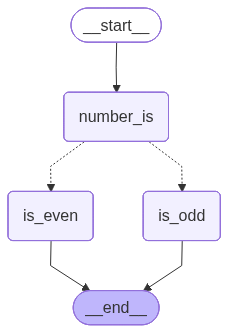

In [65]:
graph = StateGraph(State)

graph.add_node('is_even', is_even)
graph.add_node('is_odd', is_odd)
graph.add_node('number_is', number_is)

graph.add_edge(START, 'number_is')
graph.add_conditional_edges('number_is', check_condition)
graph.add_edge('is_even', END)
graph.add_edge('is_odd', END)

graph.compile()

In [66]:
workflow = graph.compile()

In [68]:
initial_state = {"value": 2}

workflow.invoke(initial_state)

{'value': 2, 'result': 'even number', 'number': 'The number is 2'}